# Adaptive Beamforming (MVDR) - Part B: Mathematical Derivations

## 🎯 Learning Objectives

This notebook provides a **step-by-step mathematical derivation** of the MVDR beamformer:

- 📐 **Signal Model**: Multi-microphone signal representation
- 🎯 **Optimization Problem**: Minimize noise while preserving speech
- 🔧 **Lagrange Multipliers**: Solving constrained optimization
- ✨ **MVDR Solution**: Closed-form optimal weights
- 📊 **Visual Derivations**: Every step illustrated

---

## 📖 Navigation

**Part A**: Foundations & Intuition  
**Part B (Current)**: Mathematical Derivations  
**Part C**: Implementation & Visualization  
**Part D**: Demonstrations & Analysis

---

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Constants
SPEED_OF_SOUND = 343  # m/s
SAMPLE_RATE = 16000   # Hz

print("✓ Libraries imported successfully!")
print("✓ Ready for MVDR mathematical derivations")

✓ Libraries imported successfully!
✓ Ready for MVDR mathematical derivations


---

# Part 1: Signal Model

Before deriving MVDR, we need to understand how to mathematically represent signals from multiple microphones.

---

## 1.1 Single Microphone Signal

At a single microphone, the received signal is:

$$x(t) = s(t) + n(t)$$

Where:
- $s(t)$ = desired speech signal
- $n(t)$ = noise signal
- $x(t)$ = observed (recorded) signal

**Problem**: We can't separate $s(t)$ from $n(t)$ with just one microphone!

**Solution**: Use multiple microphones and exploit spatial information.

# Adaptive Beamforming (MVDR) - Part B: Mathematical Derivations

## 🎯 Learning Objectives

This notebook provides a **step-by-step mathematical derivation** of the MVDR beamformer:

- 📐 **Signal Model**: Multi-microphone signal representation
- 🎯 **Optimization Problem**: Minimize noise while preserving speech
- 🔧 **Lagrange Multipliers**: Solving constrained optimization
- ✨ **MVDR Solution**: Closed-form optimal weights
- 📊 **Visual Derivations**: Every step illustrated

---

## 📖 Navigation

**Part A**: Foundations & Intuition  
**Part B (Current)**: Mathematical Derivations  
**Part C**: Implementation & Visualization  
**Part D**: Demonstrations & Analysis

---

## 1.2 Multi-Microphone Signal Model

With $M$ microphones, we have $M$ signals. At time $t$:

$$\mathbf{x}(t) = \begin{bmatrix} x_1(t) \\ x_2(t) \\ \vdots \\ x_M(t) \end{bmatrix} = \begin{bmatrix} s_1(t) + n_1(t) \\ s_2(t) + n_2(t) \\ \vdots \\ s_M(t) + n_M(t) \end{bmatrix}$$

### Key Insight: Speech is Coherent!

Speech arrives from a **specific direction** $\theta_0$, so:

$$s_m(t) = s(t - \tau_m)$$

Where $\tau_m$ is the time delay to microphone $m$.

### Frequency Domain Representation

In frequency domain (after Fourier transform), time delays become phase shifts:

$$\mathbf{X}(f) = \mathbf{a}(\theta_0, f) S(f) + \mathbf{N}(f)$$

Where:
- $\mathbf{X}(f) = [X_1(f), X_2(f), ..., X_M(f)]^T$ = observed signals
- $\mathbf{a}(\theta_0, f)$ = **steering vector** (encodes direction)
- $S(f)$ = speech signal (scalar)
- $\mathbf{N}(f) = [N_1(f), N_2(f), ..., N_M(f)]^T$ = noise signals

## 1.3 The Steering Vector

The **steering vector** $\mathbf{a}(\theta, f)$ describes how a signal from direction $\theta$ appears at all microphones.

For a 2-microphone array:

$$\mathbf{a}(\theta, f) = \begin{bmatrix} 1 \\ e^{-j2\pi f \tau(\theta)} \end{bmatrix}$$

Where:
- First mic is reference (phase = 0)
- Second mic has phase shift based on time delay $\tau(\theta) = \frac{d \sin(\theta)}{c}$

For $M$ microphones:

$$\mathbf{a}(\theta, f) = \begin{bmatrix} 1 \\ e^{-j2\pi f \tau_1(\theta)} \\ e^{-j2\pi f \tau_2(\theta)} \\ \vdots \\ e^{-j2\pi f \tau_{M-1}(\theta)} \end{bmatrix}$$


## Q: What is `a(θ₀, f)` in the signal model?

$$\mathbf{X}(f) = \mathbf{a}(\theta_0, f) S(f) + \mathbf{N}(f)$$
**`a(θ₀, f)`** is the **steering vector** — a vector of complex phase shifts, one per microphone.

---

### What it represents

For an array of **M microphones**, it's an **M×1 vector**:
$$\mathbf{a}(\theta_0, f) = \begin{bmatrix} e^{j\phi_1} \\ e^{j\phi_2} \\ \vdots \\ e^{j\phi_M} \end{bmatrix}$$
where each **φₘ** is the phase shift at microphone **m** due to the **time delay** of the wavefront arriving from direction **θ₀**.

---

### Where the phase comes from

For a **linear array**, the phase for mic **m** is:
$$\phi_m = -2\pi f \cdot \tau_m(\theta_0)$$
where **τₘ(θ₀)** is the **time delay** for the wavefront to travel from a reference point to mic **m**:
$$\tau_m(\theta_0) = \frac{d_m \sin(\theta_0)}{c}$$

- **$d_m$** = position of mic m  
- **$c$** = speed of sound  
- **$\theta_0$** = direction of arrival

---

### Intuition

| Element | Meaning |
|---|---|
| Magnitude = 1 | Signal arrives with same strength at all mics (far-field assumption) |
| Phase φₘ | How much the wavefront is **delayed/advanced** at mic m relative to reference |

> The steering vector encodes **"what the array should see"** if a source is coming from direction **θ₀** at frequency **f**.

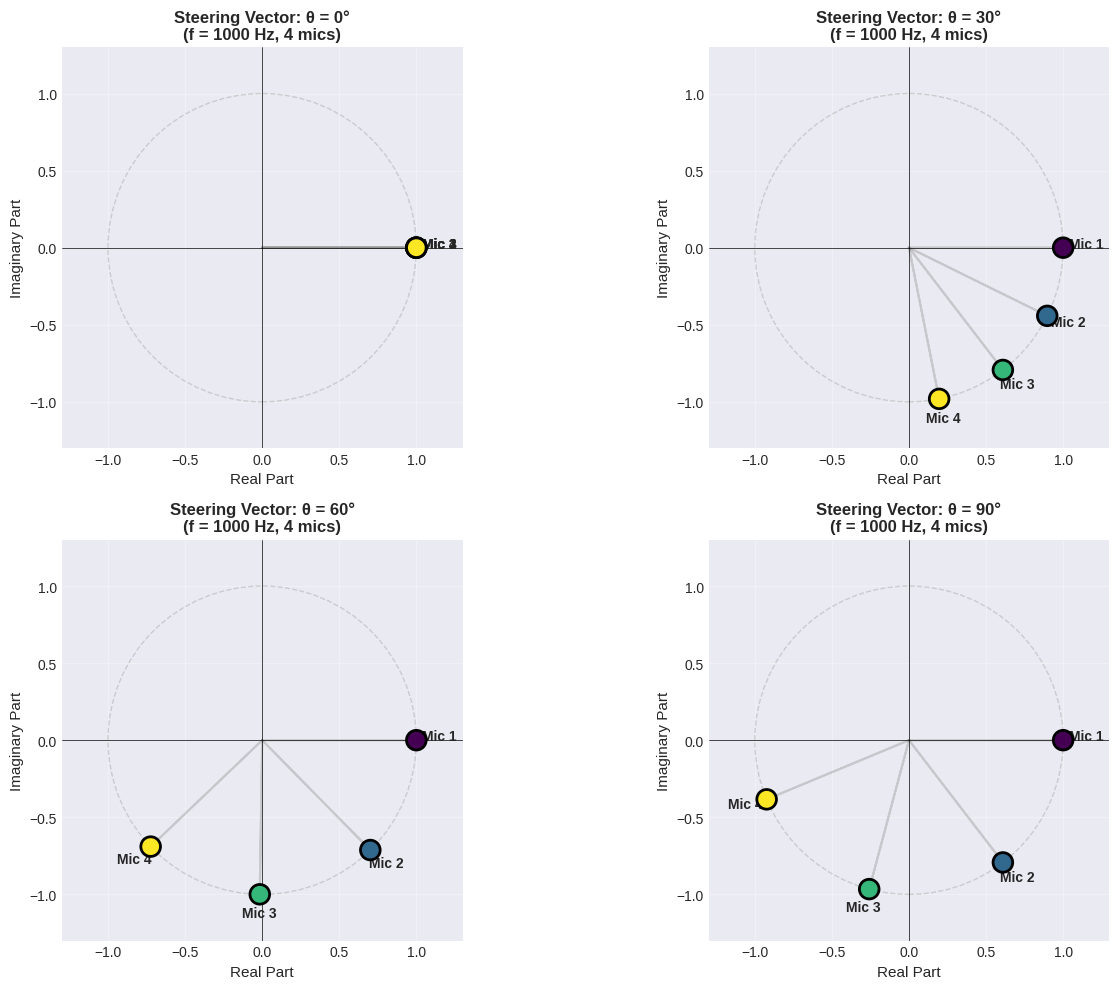


STEERING VECTOR INTERPRETATION:
• Each point represents one microphone's response
• Position in complex plane = magnitude and phase
• At 0°: All mics in phase (points aligned)
• At 90°: Maximum phase difference (points spread)
• Steering vector encodes the spatial signature of direction θ


In [2]:
def compute_steering_vector(theta_deg, freq, d=0.05, n_mics=2):
    """
    Compute steering vector for a linear array.
    
    Args:
        theta_deg: Direction of arrival (degrees)
        freq: Frequency (Hz)
        d: Microphone spacing (meters)
        n_mics: Number of microphones
    
    Returns:
        a: Steering vector (complex, shape [n_mics])
    """
    theta_rad = np.radians(theta_deg)
    a = np.zeros(n_mics, dtype=complex)
    
    for m in range(n_mics):
        # Time delay for mic m
        tau_m = (m * d * np.sin(theta_rad)) / SPEED_OF_SOUND
        # Phase shift
        a[m] = np.exp(-1j * 2 * np.pi * freq * tau_m)
    
    return a

def visualize_steering_vector():
    """
    Visualize steering vector for different directions.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    freq = 1000  # Hz
    d = 0.05     # 5cm spacing
    n_mics = 4
    
    angles = [0, 30, 60, 90]
    
    for idx, (ax, theta) in enumerate(zip(axes.flatten(), angles)):
        a = compute_steering_vector(theta, freq, d, n_mics)
        
        # Plot in complex plane
        ax.scatter(a.real, a.imag, s=200, c=range(n_mics), cmap='viridis', 
                  edgecolors='black', linewidths=2, zorder=5)
        
        # Draw arrows from origin
        for m in range(n_mics):
            ax.arrow(0, 0, a[m].real, a[m].imag, head_width=0.05, head_length=0.05,
                    fc='gray', ec='gray', alpha=0.3, linewidth=1.5)
            ax.text(a[m].real*1.15, a[m].imag*1.15, f'Mic {m+1}', 
                   fontsize=10, ha='center', weight='bold')
        
        # Unit circle
        circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', alpha=0.3)
        ax.add_patch(circle)
        
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_xlabel('Real Part', fontsize=11)
        ax.set_ylabel('Imaginary Part', fontsize=11)
        ax.set_title(f'Steering Vector: θ = {theta}°\n(f = {freq} Hz, {n_mics} mics)', 
                    fontsize=12, weight='bold')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)
        ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("STEERING VECTOR INTERPRETATION:")
    print("="*70)
    print("• Each point represents one microphone's response")
    print("• Position in complex plane = magnitude and phase")
    print("• At 0°: All mics in phase (points aligned)")
    print("• At 90°: Maximum phase difference (points spread)")
    print("• Steering vector encodes the spatial signature of direction θ")
    print("="*70)

visualize_steering_vector()

## 1.4 Beamformer Output

A beamformer applies **weights** $\mathbf{w}$ to the microphone signals:

$$Y(f) = \mathbf{w}^H \mathbf{X}(f)$$

Where:
- $\mathbf{w} = [w_1, w_2, ..., w_M]^T$ = complex weights
- $\mathbf{w}^H$ = Hermitian transpose (transpose + conjugate)
- $Y(f)$ = beamformer output (scalar)

Expanding:

$$Y(f) = \mathbf{w}^H [\mathbf{a}(\theta_0, f) S(f) + \mathbf{N}(f)]$$
$$Y(f) = \underbrace{\mathbf{w}^H \mathbf{a}(\theta_0, f)}_{\text{speech gain}} S(f) + \underbrace{\mathbf{w}^H \mathbf{N}(f)}_{\text{noise output}}$$

**Goal**: Choose $\mathbf{w}$ to:
1. Preserve speech: $\mathbf{w}^H \mathbf{a}(\theta_0, f) = 1$ (no distortion)
2. Minimize noise: $|\mathbf{w}^H \mathbf{N}(f)|^2$ as small as possible

---

# Part 2: MVDR Optimization Problem

Now we formulate the mathematical optimization problem that MVDR solves.

---

## 2.1 Noise Power at Output

The noise power at the beamformer output is:

$$P_n = E[|\mathbf{w}^H \mathbf{N}(f)|^2]$$

Where $E[\cdot]$ is the expected value (average).

Using properties of expectation:

$$P_n = E[\mathbf{w}^H \mathbf{N}(f) \mathbf{N}^H(f) \mathbf{w}]$$
$$P_n = \mathbf{w}^H E[\mathbf{N}(f) \mathbf{N}^H(f)] \mathbf{w}$$
$$P_n = \mathbf{w}^H \mathbf{R}_n(f) \mathbf{w}$$

Where:
$$\mathbf{R}_n(f) = E[\mathbf{N}(f) \mathbf{N}^H(f)]$$

is the **noise covariance matrix**.

### What is the Noise Covariance Matrix?

For 2 microphones:

$$\mathbf{R}_n = \begin{bmatrix} E[|N_1|^2] & E[N_1 N_2^*] \\ E[N_2 N_1^*] & E[|N_2|^2] \end{bmatrix} = \begin{bmatrix} \sigma_1^2 & \rho_{12} \\ \rho_{21} & \sigma_2^2 \end{bmatrix}$$

- **Diagonal**: Noise power at each mic
- **Off-diagonal**: Correlation between mics

## 2.2 The MVDR Optimization Problem

**MVDR** = **M**inimum **V**ariance **D**istortionless **R**esponse

### Mathematical Formulation:

$$\begin{align}
\min_{\mathbf{w}} \quad & \mathbf{w}^H \mathbf{R}_n \mathbf{w} \\
\text{subject to} \quad & \mathbf{w}^H \mathbf{a}(\theta_0) = 1
\end{align}$$

### In Plain English:

**Minimize**: Noise power at output ($\mathbf{w}^H \mathbf{R}_n \mathbf{w}$)  
**Subject to**: Speech from direction $\theta_0$ is not distorted ($\mathbf{w}^H \mathbf{a}(\theta_0) = 1$)

### Why This Works:

1. **Constraint** ensures speech is preserved (gain = 1, no phase shift)
2. **Objective** minimizes noise while satisfying constraint
3. **Result**: Optimal weights that suppress noise without distorting speech!

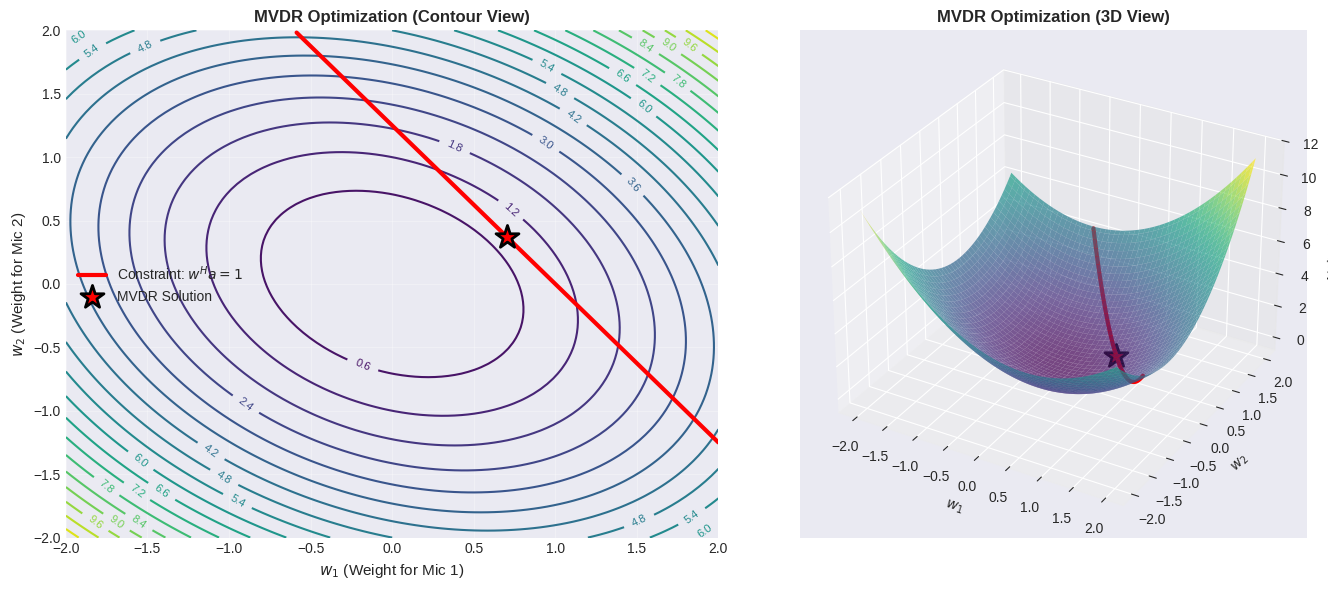


OPTIMIZATION PROBLEM VISUALIZATION:
• Contours: Noise power levels (want to minimize)
• Red line: Constraint (must stay on this line)
• Red star: MVDR solution (minimum noise on constraint)
• Optimal weights: w1 = 0.706, w2 = 0.368
• Minimum noise power: 0.816


In [ ]:
def visualize_optimization_problem():
    """
    Visualize the MVDR optimization problem geometrically.
    """
    fig = plt.figure(figsize=(14, 6))
    
    # Simple 2D case for visualization
    # Let w = [w1, w2] (real for simplicity)
    
    # Create grid
    w1 = np.linspace(-2, 2, 100)
    w2 = np.linspace(-2, 2, 100)
    W1, W2 = np.meshgrid(w1, w2)
    
    # Noise covariance (example)
    R_n = np.array([[1.0, 0.3],
                    [0.3, 1.2]])
    
    # Compute objective function: w^H R_n w
    Z = np.zeros_like(W1)
    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            w = np.array([W1[i,j], W2[i,j]])
            Z[i,j] = w @ R_n @ w  #not using Hermitian transpose here due to reduce complexity.
    
    # Steering vector (example)
    a = np.array([1.0, 0.8])
    
    # Constraint: w^H a = 1
    # For real case: w1*a1 + w2*a2 = 1
    # w2 = (1 - w1*a1) / a2
    w1_constraint = np.linspace(-2, 2, 100)
    w2_constraint = (1 - w1_constraint * a[0]) / a[1]
    
    # Plot 1: Contour plot
    ax1 = fig.add_subplot(121)
    contour = ax1.contour(W1, W2, Z, levels=20, cmap='viridis')
    ax1.clabel(contour, inline=True, fontsize=8)
    
    # Plot constraint line
    mask = (w2_constraint >= -2) & (w2_constraint <= 2)
    ax1.plot(w1_constraint[mask], w2_constraint[mask], 'r-', linewidth=3, 
            label='Constraint: $w^H a = 1$')
    
    # Find optimal point (intersection of constraint with minimum contour)
    # Analytical solution: w_opt = R_n^(-1) a / (a^H R_n^(-1) a)
    R_n_inv = np.linalg.inv(R_n)
    w_opt = R_n_inv @ a / (a @ R_n_inv @ a)
    ax1.scatter([w_opt[0]], [w_opt[1]], s=300, c='red', marker='*', 
               edgecolors='black', linewidths=2, zorder=10, label='MVDR Solution')
    
    ax1.set_xlabel('$w_1$ (Weight for Mic 1)', fontsize=11)
    ax1.set_ylabel('$w_2$ (Weight for Mic 2)', fontsize=11)
    ax1.set_title('MVDR Optimization (Contour View)', fontsize=12, weight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-2, 2)
    ax1.set_ylim(-2, 2)
    
    # Plot 2: 3D surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.7, edgecolor='none')
    
    # Plot constraint line in 3D
    z_constraint = np.array([w @ R_n @ w for w in zip(w1_constraint[mask], w2_constraint[mask])])
    ax2.plot(w1_constraint[mask], w2_constraint[mask], z_constraint, 'r-', 
            linewidth=3, label='Constraint')
    
    # Plot optimal point
    z_opt = w_opt @ R_n @ w_opt
    ax2.scatter([w_opt[0]], [w_opt[1]], [z_opt], s=300, c='red', marker='*',
               edgecolors='black', linewidths=2, zorder=10)
    
    ax2.set_xlabel('$w_1$', fontsize=10)
    ax2.set_ylabel('$w_2$', fontsize=10)
    ax2.set_zlabel('Noise Power', fontsize=10)
    ax2.set_title('MVDR Optimization (3D View)', fontsize=12, weight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("OPTIMIZATION PROBLEM VISUALIZATION:")
    print("="*70)
    print("• Contours: Noise power levels (want to minimize)")
    print("• Red line: Constraint (must stay on this line)")
    print("• Red star: MVDR solution (minimum noise on constraint)")
    print(f"• Optimal weights: w1 = {w_opt[0]:.3f}, w2 = {w_opt[1]:.3f}")
    print(f"• Minimum noise power: {z_opt:.3f}")
    print("="*70)

visualize_optimization_problem()

---

# Part 3: Solving with Lagrange Multipliers

To solve the constrained optimization problem, we use the **method of Lagrange multipliers**.

---

## 3.1 What is a Lagrange Multiplier?

### The Intuition:

Imagine you want to minimize $f(x, y)$ subject to $g(x, y) = c$.

**Key Insight**: At the optimal point, the gradient of $f$ must be parallel to the gradient of $g$.

$$\nabla f = \lambda \nabla g$$

Where $\lambda$ is the **Lagrange multiplier**.

### For MVDR:

- Objective: $f(\mathbf{w}) = \mathbf{w}^H \mathbf{R}_n \mathbf{w}$
- Constraint: $g(\mathbf{w}) = \mathbf{w}^H \mathbf{a} - 1 = 0$

We form the **Lagrangian**:

$$\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^H \mathbf{R}_n \mathbf{w} + \lambda (\mathbf{w}^H \mathbf{a} - 1)$$

## 3.2 Taking the Derivative

To find the minimum, we take the derivative with respect to $\mathbf{w}^*$ (complex conjugate) and set it to zero:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}^*} = 0$$

### Step-by-Step:

**Step 1**: Derivative of $\mathbf{w}^H \mathbf{R}_n \mathbf{w}$

Using the identity: $\frac{\partial (\mathbf{w}^H \mathbf{A} \mathbf{w})}{\partial \mathbf{w}^*} = \mathbf{A} \mathbf{w}$

$$\frac{\partial (\mathbf{w}^H \mathbf{R}_n \mathbf{w})}{\partial \mathbf{w}^*} = \mathbf{R}_n \mathbf{w}$$

**Step 2**: Derivative of $\lambda (\mathbf{w}^H \mathbf{a} - 1)$

$$\frac{\partial (\lambda \mathbf{w}^H \mathbf{a})}{\partial \mathbf{w}^*} = \lambda \mathbf{a}$$

**Step 3**: Combine and set to zero

$$\mathbf{R}_n \mathbf{w} + \lambda \mathbf{a} = 0$$

**Step 4**: Solve for $\mathbf{w}$

$$\mathbf{R}_n \mathbf{w} = -\lambda \mathbf{a}$$
$$\mathbf{w} = -\lambda \mathbf{R}_n^{-1} \mathbf{a}$$

## 3.3 Finding λ (Lambda)

We still need to find $\lambda$. Use the constraint:

$$\mathbf{w}^H \mathbf{a} = 1$$

Substitute $\mathbf{w} = -\lambda \mathbf{R}_n^{-1} \mathbf{a}$:

$$(-\lambda \mathbf{R}_n^{-1} \mathbf{a})^H \mathbf{a} = 1$$
$$-\lambda^* \mathbf{a}^H \mathbf{R}_n^{-1} \mathbf{a} = 1$$

Since $\mathbf{R}_n$ is Hermitian, $\mathbf{a}^H \mathbf{R}_n^{-1} \mathbf{a}$ is real, so:

$$\lambda = -\frac{1}{\mathbf{a}^H \mathbf{R}_n^{-1} \mathbf{a}}$$

## 3.4 Final MVDR Solution

Substitute $\lambda$ back into $\mathbf{w} = -\lambda \mathbf{R}_n^{-1} \mathbf{a}$:

$$\mathbf{w}_{\text{MVDR}} = -\left(-\frac{1}{\mathbf{a}^H \mathbf{R}_n^{-1} \mathbf{a}}\right) \mathbf{R}_n^{-1} \mathbf{a}$$

### 🎉 MVDR Beamformer Weights:

$$\boxed{\mathbf{w}_{\text{MVDR}} = \frac{\mathbf{R}_n^{-1} \mathbf{a}}{\mathbf{a}^H \mathbf{R}_n^{-1} \mathbf{a}}}$$

### Understanding Each Term:

1. **$\mathbf{R}_n^{-1}$**: Inverse noise covariance ("undo" noise correlation)
2. **$\mathbf{R}_n^{-1} \mathbf{a}$**: Point in direction $\theta_0$, accounting for noise
3. **$\mathbf{a}^H \mathbf{R}_n^{-1} \mathbf{a}$**: Normalization (ensures constraint is satisfied)

### Key Properties:

- ✅ Automatically satisfies constraint: $\mathbf{w}_{\text{MVDR}}^H \mathbf{a} = 1$
- ✅ Minimizes noise power: $\mathbf{w}_{\text{MVDR}}^H \mathbf{R}_n \mathbf{w}_{\text{MVDR}}$
- ✅ Adapts to noise statistics (through $\mathbf{R}_n$)
- ✅ Creates nulls automatically in noise directions

In [4]:
def compute_mvdr_weights(R_n, a):
    """
    Compute MVDR beamformer weights.
    
    Args:
        R_n: Noise covariance matrix [M x M]
        a: Steering vector [M]
    
    Returns:
        w_mvdr: MVDR weights [M]
    """
    R_n_inv = np.linalg.inv(R_n)
    numerator = R_n_inv @ a
    denominator = np.conj(a) @ R_n_inv @ a
    w_mvdr = numerator / denominator
    return w_mvdr

def demonstrate_mvdr_solution():
    """
    Demonstrate MVDR solution with numerical example.
    """
    print("="*70)
    print("MVDR SOLUTION: NUMERICAL EXAMPLE")
    print("="*70)
    
    # Example: 2-mic array
    print("\nSetup: 2-microphone array")
    print("  • Mic spacing: 5 cm")
    print("  • Speech direction: 0° (front)")
    print("  • Noise: More power at Mic 2, correlated")
    print("  • Frequency: 1000 Hz")
    
    # Steering vector (speech from 0°)
    theta_speech = 0
    freq = 1000
    a = compute_steering_vector(theta_speech, freq, d=0.05, n_mics=2)
    
    print(f"\nSteering vector a:")
    print(f"  a = [{a[0]:.3f}, {a[1]:.3f}]")
    print(f"  (Both mics in phase since speech is at 0°)")
    
    # Noise covariance matrix
    R_n = np.array([[1.0, 0.3],
                    [0.3, 1.5]], dtype=complex)
    
    print(f"\nNoise covariance matrix R_n:")
    print(f"  [[{R_n[0,0]:.1f}, {R_n[0,1]:.1f}]")
    print(f"   [{R_n[1,0]:.1f}, {R_n[1,1]:.1f}]]")
    print(f"  • Mic 2 has more noise (1.5 vs 1.0)")
    print(f"  • Mics are correlated (0.3)")
    
    # Compute MVDR weights
    w_mvdr = compute_mvdr_weights(R_n, a)
    
    print(f"\nMVDR weights w:")
    print(f"  w = [{w_mvdr[0]:.3f}, {w_mvdr[1]:.3f}]")
    print(f"  • Mic 1 weight: {abs(w_mvdr[0]):.3f} (magnitude)")
    print(f"  • Mic 2 weight: {abs(w_mvdr[1]):.3f} (magnitude)")
    print(f"  • Mic 2 gets LOWER weight (has more noise!)")
    
    # Verify constraint
    constraint_check = np.conj(w_mvdr) @ a
    print(f"\nConstraint verification:")
    print(f"  w^H a = {constraint_check:.6f}")
    print(f"  ✓ Equals 1.0 (constraint satisfied!)")
    
    # Compute noise power
    noise_power = np.real(np.conj(w_mvdr) @ R_n @ w_mvdr)
    print(f"\nNoise power at output:")
    print(f"  w^H R_n w = {noise_power:.3f}")
    
    # Compare with equal weights (fixed beamforming)
    w_fixed = np.array([0.5, 0.5])
    noise_power_fixed = np.real(np.conj(w_fixed) @ R_n @ w_fixed)
    improvement = 10 * np.log10(noise_power_fixed / noise_power)
    
    print(f"\nComparison with fixed beamforming:")
    print(f"  Fixed (equal weights): {noise_power_fixed:.3f}")
    print(f"  MVDR (adaptive): {noise_power:.3f}")
    print(f"  Improvement: {improvement:.2f} dB")
    
    print("\n" + "="*70)
    print("KEY INSIGHT:")
    print("MVDR automatically reduces weight on noisier microphone!")
    print("This is adaptation in action - weights depend on noise statistics.")
    print("="*70)

demonstrate_mvdr_solution()

MVDR SOLUTION: NUMERICAL EXAMPLE

Setup: 2-microphone array
  • Mic spacing: 5 cm
  • Speech direction: 0° (front)
  • Noise: More power at Mic 2, correlated
  • Frequency: 1000 Hz

Steering vector a:
  a = [1.000+0.000j, 1.000+0.000j]
  (Both mics in phase since speech is at 0°)

Noise covariance matrix R_n:
  [[1.0+0.0j, 0.3+0.0j]
   [0.3+0.0j, 1.5+0.0j]]
  • Mic 2 has more noise (1.5 vs 1.0)
  • Mics are correlated (0.3)

MVDR weights w:
  w = [0.632+0.000j, 0.368+0.000j]
  • Mic 1 weight: 0.632 (magnitude)
  • Mic 2 weight: 0.368 (magnitude)
  • Mic 2 gets LOWER weight (has more noise!)

Constraint verification:
  w^H a = 1.000000+0.000000j
  ✓ Equals 1.0 (constraint satisfied!)

Noise power at output:
  w^H R_n w = 0.742

Comparison with fixed beamforming:
  Fixed (equal weights): 0.775
  MVDR (adaptive): 0.742
  Improvement: 0.19 dB

KEY INSIGHT:
MVDR automatically reduces weight on noisier microphone!
This is adaptation in action - weights depend on noise statistics.


---

# Summary of Part B

## What We Derived:

### 1. Signal Model
- Multi-microphone signals: $\mathbf{X}(f) = \mathbf{a}(\theta_0, f) S(f) + \mathbf{N}(f)$
- Steering vector: Encodes spatial signature of direction
- Beamformer output: $Y(f) = \mathbf{w}^H \mathbf{X}(f)$

### 2. MVDR Optimization
- **Objective**: Minimize noise power $\mathbf{w}^H \mathbf{R}_n \mathbf{w}$
- **Constraint**: Preserve speech $\mathbf{w}^H \mathbf{a} = 1$
- **Method**: Lagrange multipliers

### 3. MVDR Solution
$$\mathbf{w}_{\text{MVDR}} = \frac{\mathbf{R}_n^{-1} \mathbf{a}}{\mathbf{a}^H \mathbf{R}_n^{-1} \mathbf{a}}$$

### 4. Key Properties
- ✅ Adapts to noise statistics (through $\mathbf{R}_n$)
- ✅ Automatically reduces weight on noisier mics
- ✅ Creates nulls in noise directions
- ✅ Preserves speech without distortion

---

## Next Steps

**Part C**: Implementation & Visualization
- How to estimate $\mathbf{R}_n$ from data
- Computing MVDR weights in practice
- Visualizing adaptive beam patterns
- Complete Python implementation

**Part D**: Demonstrations & Analysis
- Real-world scenarios
- Performance comparisons
- Practical considerations

---